# Membership Inference Attack (Appendix F.3)

This notebook implements the **Shokri et al. (2017)** membership inference attack
against our TOFU-trained Pythia-160M unlearning models.

**Core idea (from the paper):**
> A model often behaves differently on data it was trained on versus data it has
> never seen. An attacker can train an *attack model* to exploit this difference
> and determine whether a given record was in the target model's training dataset.

**Our adaptation:**
- **Target models**: MaxEnt and UNDO unlearned + distilled Pythia-160M checkpoints
- **Member set**: TOFU `forget10` — the data the model was *fine-tuned* on
- **Non-member set**: TOFU `retain90` — data the model was *not* trained to forget
- **Attack signal**: Per-token cross-entropy loss (log-perplexity) — lower loss = likely member
- **Attack classifier**: Logistic regression on loss features (shadow-free, loss-based variant)

**Key question:** After unlearning, does the model still exhibit lower loss on forget-set
records than retain-set records? If yes, the unlearning is incomplete from a
membership-inference perspective.

**Metrics reported:**
| Metric | Meaning |
|---|---|
| Attack AUC | Area under ROC curve — higher = more membership leakage |
| Attack Accuracy | Fraction of correct member/non-member classifications |
| Precision | Fraction of predicted members that are true members |
| Recall | Fraction of true members correctly identified |
| TPR @ 5% FPR | True positive rate at low false positive rate (privacy-critical threshold) |

## 1. Setup

In [23]:
import os
import gc
import json
import random
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, roc_curve,
)
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

REPO_DIR   = Path("/lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338")
MODELS_DIR = REPO_DIR / "models"
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Repo   : {REPO_DIR}")
print(f"Device : {DEVICE}")
print(f"Torch  : {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Repo   : /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338
Device : cuda
Torch  : 2.4.0
GPU    : NVIDIA H100 80GB HBM3


## 2. Configuration

In [24]:
BASE_MODEL_ID = "EleutherAI/pythia-160m"

MODEL_CONFIGS = [
    {
        "family": "Baseline",
        "method": "Pretrained (no fine-tuning)",
        "path": BASE_MODEL_ID,   # HuggingFace Hub — never saw TOFU data
    },
    {
        "family": "Baseline",
        "method": "Finetuned (no unlearning)",
        "path": MODELS_DIR / "maxent/pythia-160m-finetuned-tofu",
    },
    {
        "family": "MaxEnt",
        "method": "MaxEnt",
        "path": MODELS_DIR / "maxent/pythia-160m-unlearned",
    },
    {
        "family": "MaxEnt",
        "method": "MaxEnt + Distilled",
        "path": MODELS_DIR / "maxent/pythia-160m-distilled",
    },
    {
        "family": "UNDO",
        "method": "UNDO",
        "path": MODELS_DIR / "undo/pythia-160m-unlearned",
    },
    {
        "family": "UNDO",
        "method": "UNDO + Distilled",
        "path": MODELS_DIR / "undo/pythia-160m-distilled",
    },
]

# TOFU splits
# Members     = forget10 (data the model was fine-tuned on → should be forgotten)
# Non-members = retain90 (same fictional domain as forget10, never unlearned)
#
# Using retain90 rather than world_facts avoids the text-difficulty confound:
# both splits are fictional author Q&A generated with the same template, so a
# pretrained model (which saw neither) should give AUC ≈ 0.5.  Any deviation
# after unlearning measures *selective forgetting* of forget10 relative to the
# data the model was supposed to keep — the test the TOFU benchmark intends.
MEMBER_SPLIT     = "forget10"
NON_MEMBER_SPLIT = "retain90"

MAX_SAMPLES_PER_CLASS = None

MAX_LENGTH = 256

print("Checkpoint status:")
for cfg in MODEL_CONFIGS:
    p = cfg["path"]
    if isinstance(p, str):
        status = "HUB "
    elif Path(str(p)).is_dir() and (Path(str(p)) / "config.json").exists():
        status = "OK  "
    else:
        status = "MISS"
    print(f"[{status}] {cfg['method']:<30} {p}")


Checkpoint status:
[HUB ] Pretrained (no fine-tuning)    EleutherAI/pythia-160m
[OK  ] Finetuned (no unlearning)      /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338/models/maxent/pythia-160m-finetuned-tofu
[OK  ] MaxEnt                         /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338/models/maxent/pythia-160m-unlearned
[OK  ] MaxEnt + Distilled             /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338/models/maxent/pythia-160m-distilled
[OK  ] UNDO                           /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338/models/undo/pythia-160m-unlearned
[OK  ] UNDO + Distilled               /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338/models/undo/pythia-160m-distilled


## 3. Load TOFU Member / Non-Member Sets

In [25]:
import json
from pathlib import Path

FORGET_SPLIT_PATH = REPO_DIR / "notebooks/attacks/forget10_split.json"

if FORGET_SPLIT_PATH.exists():
    split_info = json.loads(FORGET_SPLIT_PATH.read_text())
    assert split_info["tofu_split"] == "forget10", "Split file is for a different TOFU split"

    _full_forget_ds = load_dataset("locuslab/TOFU", "forget10", split="train")
    member_ds       = _full_forget_ds.select(split_info["train_indices"])
    non_member_ds   = _full_forget_ds.select(split_info["heldout_indices"])

    print(f"Loaded forget10 split from {FORGET_SPLIT_PATH}")
    print(f"  Seed              : {split_info['seed']}")
    print(f"  Members (trained) : {len(member_ds)}")
    print(f"  Non-members (held-out, never seen) : {len(non_member_ds)}")
else:
    # Fallback: use full forget10 vs retain90 if no split file exists yet
    print(f"WARNING: {FORGET_SPLIT_PATH} not found.")
    print("Run the experiments-undo.ipynb split cell first to generate the held-out set.")
    print("Falling back to full forget10 (members) vs retain90 (non-members).")
    member_ds     = load_dataset("locuslab/TOFU", "forget10",  split="train")
    non_member_ds = load_dataset("locuslab/TOFU", "retain90",  split="train")

n_members     = len(member_ds)
n_non_members = len(non_member_ds)

# Balance the two sets
n = min(n_members, n_non_members)
rng = np.random.default_rng(SEED)
member_idx     = rng.choice(n_members,     size=n, replace=False)
non_member_idx = rng.choice(n_non_members, size=n, replace=False)

member_ds_balanced     = member_ds.select(member_idx)
non_member_ds_balanced = non_member_ds.select(non_member_idx)

print(f"\nBalanced evaluation set:")
print(f"  Members     : {len(member_ds_balanced)}  (forget10 train half — fine-tuned & unlearned)")
print(f"  Non-members : {len(non_member_ds_balanced)}  (forget10 held-out half — never seen by model)")


Loaded forget10 split from /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338/notebooks/attacks/forget10_split.json
  Seed              : 42
  Members (trained) : 200
  Non-members (held-out, never seen) : 200

Balanced evaluation set:
  Members     : 200  (forget10 train half — fine-tuned & unlearned)
  Non-members : 200  (forget10 held-out half — never seen by model)


## 4. Loss Extraction Helpers

In [26]:
def model_device(model):
    return next(model.parameters()).device


@torch.no_grad()
def per_token_loss(model, tokenizer, question, answer, max_length=MAX_LENGTH):
    """
    Return the mean per-token cross-entropy loss for the answer tokens.
    Returns np.nan if the sequence is too short or produces invalid loss.
    """
    prompt    = f"Question: {question}\nAnswer: "
    full_text = prompt + str(answer)

    full        = tokenizer(full_text, return_tensors="pt", truncation=True, max_length=max_length)
    prompt_only = tokenizer(prompt,    return_tensors="pt")  # no truncation — need true prompt length

    input_ids      = full["input_ids"].to(model_device(model))
    attention_mask = full["attention_mask"].to(model_device(model))

    labels = input_ids.clone()
    prompt_len = prompt_only["input_ids"].shape[1]
    labels[:, :prompt_len] = -100   # mask prompt tokens

    # If all tokens are masked there are no answer tokens to score
    if (labels != -100).sum() == 0:
        return np.nan

    outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
    loss_val = float(outputs.loss.item())

    if np.isnan(loss_val) or np.isinf(loss_val):
        return np.nan

    return loss_val


def get_qa_columns(dataset):
    """Return (question_col, answer_col) for a TOFU dataset split."""
    cols = dataset.column_names
    q_col = "question" if "question" in cols else cols[0]
    a_col = "answer"   if "answer"   in cols else cols[1]
    return q_col, a_col


def extract_losses(model, tokenizer, dataset, label_name):
    q_col, a_col = get_qa_columns(dataset)
    losses = []
    for i, ex in enumerate(dataset):
        loss = per_token_loss(model, tokenizer, ex[q_col], ex[a_col])
        losses.append(loss)
        if (i + 1) % 50 == 0:
            print(f"  {label_name}: {i + 1}/{len(dataset)}")
    arr = np.array(losses, dtype=np.float64)
    n_nan = np.isnan(arr).sum()
    if n_nan > 0:
        print(f"  WARNING: {label_name} has {n_nan}/{len(arr)} NaN losses (will be dropped)")
    return arr


def load_model(model_path):
    # model_path may be a local Path or a HuggingFace Hub model ID string
    model_id = str(model_path)
    is_local = Path(model_id).is_dir()

    if is_local and not (Path(model_id) / "config.json").exists():
        raise FileNotFoundError(f"No config.json in {model_id}")

    dtype = torch.float16 if torch.cuda.is_available() else torch.float32
    kwargs = {"local_files_only": True} if is_local else {}

    try:
        tokenizer = AutoTokenizer.from_pretrained(model_id, padding_side="left", **kwargs)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, padding_side="left")

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=dtype,
        device_map="auto" if torch.cuda.is_available() else None,
        **kwargs,
    )
    model.eval()
    return model, tokenizer


def cleanup_model(model):
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()


## 5. Attack Classifier Helpers

In [27]:
def run_attack(member_losses, non_member_losses):
    """
    Train a logistic regression attack classifier on per-token losses.

    Features  : [loss]          (scalar per record)
    Labels    : 1 = member, 0 = non-member

    This implements the loss-threshold variant of Shokri et al.:
    the attack model learns a threshold on the target model's loss
    to distinguish members from non-members.
    """
    X = np.concatenate([member_losses, non_member_losses]).reshape(-1, 1)
    y = np.array([1] * len(member_losses) + [0] * len(non_member_losses))

    # Drop NaN/Inf entries
    valid = np.isfinite(X.squeeze())
    X, y = X[valid], y[valid]
    print(f"  Attack: {valid.sum()}/{len(valid)} valid samples after NaN drop")

    if len(np.unique(y)) < 2:
        raise ValueError("Only one class after NaN drop — cannot train classifier. "
                         "Check column names or model outputs.")

    # Stratified 80/20 split
    rng   = np.random.default_rng(SEED)
    idx   = rng.permutation(len(X))
    split = int(0.8 * len(idx))
    tr, te = idx[:split], idx[split:]

    clf = LogisticRegression(max_iter=1000, random_state=SEED)
    clf.fit(X[tr], y[tr])

    y_pred  = clf.predict(X[te])
    y_score = clf.predict_proba(X[te])[:, 1]
    y_true  = y[te]

    auc       = roc_auc_score(y_true, y_score)
    acc       = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)

    # TPR @ 5% FPR
    fpr, tpr, _ = roc_curve(y_true, y_score)
    tpr_at_5fpr = float(np.interp(0.05, fpr, tpr))

    return {
        "AUC":               auc,
        "Accuracy":          acc,
        "Precision":         precision,
        "Recall":            recall,
        "TPR @ 5% FPR":     tpr_at_5fpr,
        "fpr":               fpr,
        "tpr":               tpr,
        "member_losses":     member_losses,
        "non_member_losses": non_member_losses,
    }


## 6. Run Membership Inference Attack

In [28]:
results = []
roc_data = {}

for cfg in MODEL_CONFIGS:
    print("=" * 80)
    print(f"Attacking {cfg['method']} [{cfg['family']}]")
    print(f"Path: {cfg['path']}")
    print("=" * 80)

    try:
        model, tokenizer = load_model(cfg["path"])

        print("  Extracting member losses (forget set)...")
        member_losses = extract_losses(model, tokenizer, member_ds_balanced, "member")

        print("  Extracting non-member losses (retain set)...")
        non_member_losses = extract_losses(model, tokenizer, non_member_ds_balanced, "non-member")

        cleanup_model(model)

        print("  Running attack classifier...")
        attack = run_attack(member_losses, non_member_losses)

        roc_data[cfg["method"]] = (attack["fpr"], attack["tpr"])

        row = {
            "Family":        cfg["family"],
            "Method":        cfg["method"],
            "AUC":           round(attack["AUC"], 3),
            "Accuracy":      round(attack["Accuracy"], 3),
            "Precision":     round(attack["Precision"], 3),
            "Recall":        round(attack["Recall"], 3),
            "TPR @ 5% FPR": round(attack["TPR @ 5% FPR"], 3),
            "Mean Member Loss":     round(float(np.nanmean(member_losses)), 4),
            "Mean Non-Member Loss": round(float(np.nanmean(non_member_losses)), 4),
        }
        results.append(row)
        print(f"  AUC={row['AUC']:.3f}  Acc={row['Accuracy']:.3f}  "
              f"Prec={row['Precision']:.3f}  Rec={row['Recall']:.3f}  "
              f"TPR@5FPR={row['TPR @ 5% FPR']:.3f}")

    except Exception as e:
        import traceback
        print(f"FAILED: {cfg['method']}: {e}")
        traceback.print_exc()
        results.append({
            "Family": cfg["family"], "Method": cfg["method"],
            "AUC": np.nan, "Accuracy": np.nan, "Precision": np.nan,
            "Recall": np.nan, "TPR @ 5% FPR": np.nan,
            "Mean Member Loss": np.nan, "Mean Non-Member Loss": np.nan,
            "Error": str(e),
        })

df = pd.DataFrame(results)
df

Attacking Pretrained (no fine-tuning) [Baseline]
Path: EleutherAI/pythia-160m


  Extracting member losses (forget set)...
  member: 50/200
  member: 100/200
  member: 150/200
  member: 200/200
  Extracting non-member losses (retain set)...
  non-member: 50/200
  non-member: 100/200
  non-member: 150/200
  non-member: 200/200
  Running attack classifier...
  Attack: 400/400 valid samples after NaN drop
  AUC=0.477  Acc=0.412  Prec=0.000  Rec=0.000  TPR@5FPR=0.000
Attacking Finetuned (no unlearning) [Baseline]
Path: /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338/models/maxent/pythia-160m-finetuned-tofu
  Extracting member losses (forget set)...
  member: 50/200
  member: 100/200
  member: 150/200
  member: 200/200
  Extracting non-member losses (retain set)...
  non-member: 50/200
  non-member: 100/200
  non-member: 150/200
  non-member: 200/200
  Running attack classifier...
  Attack: 400/400 valid samples after NaN drop
  AUC=0.943  Acc=0.925  Prec=0.902  Rec=0.979  TPR@5FPR=0.489
Attacking MaxEnt [MaxEnt]
Path: /lustre/fsw/portfolios/s

,Family,Method,AUC,Accuracy,Precision,Recall,TPR @ 5% FPR,Mean Member Loss,Mean Non-Member Loss
0,Baseline,Pretrained (no fine-tuning),0.477,0.412,0.000,0.000,0.000,2.7171,2.7256
1,Baseline,Finetuned (no unlearning),0.943,0.925,0.902,0.979,0.489,0.6589,2.8297
2,MaxEnt,MaxEnt,0.552,0.412,0.500,0.064,0.000,7.2594,7.1638
3,MaxEnt,MaxEnt + Distilled,0.760,0.688,0.729,0.745,0.021,1.5960,2.4178
4,UNDO,UNDO,0.466,0.338,0.000,0.000,0.000,7.6411,7.5790
5,UNDO,UNDO + Distilled,0.718,0.675,0.744,0.681,0.021,1.9179,2.7400


## 7. Results Table

In [29]:
display_cols = ["Family", "Method", "AUC", "Accuracy", "Precision",
                "Recall", "TPR @ 5% FPR", "Mean Member Loss", "Mean Non-Member Loss"]

display_df = df[[c for c in display_cols if c in df.columns]].copy()
display(display_df)

print()
print("Interpretation:")
print("  AUC = 0.5  → attack performs no better than random (unlearning successful)")
print("  AUC > 0.7  → model still leaks membership information (unlearning incomplete)")
print("  TPR@5%FPR  → how many members are identified at a low false-positive rate")

,Family,Method,AUC,Accuracy,Precision,Recall,TPR @ 5% FPR,Mean Member Loss,Mean Non-Member Loss
0,Baseline,Pretrained (no fine-tuning),0.477,0.412,0.000,0.000,0.000,2.7171,2.7256
1,Baseline,Finetuned (no unlearning),0.943,0.925,0.902,0.979,0.489,0.6589,2.8297
2,MaxEnt,MaxEnt,0.552,0.412,0.500,0.064,0.000,7.2594,7.1638
3,MaxEnt,MaxEnt + Distilled,0.760,0.688,0.729,0.745,0.021,1.5960,2.4178
4,UNDO,UNDO,0.466,0.338,0.000,0.000,0.000,7.6411,7.5790
5,UNDO,UNDO + Distilled,0.718,0.675,0.744,0.681,0.021,1.9179,2.7400



Interpretation:
  AUC = 0.5  → attack performs no better than random (unlearning successful)
  AUC > 0.7  → model still leaks membership information (unlearning incomplete)
  TPR@5%FPR  → how many members are identified at a low false-positive rate


## 8. Loss Distribution Analysis

  member: 50/200
  member: 100/200
  member: 150/200
  member: 200/200
  non-member: 50/200
  non-member: 100/200
  non-member: 150/200
  non-member: 200/200
  member: 50/200
  member: 100/200
  member: 150/200
  member: 200/200
  non-member: 50/200
  non-member: 100/200
  non-member: 150/200
  non-member: 200/200
  member: 50/200
  member: 100/200
  member: 150/200
  member: 200/200
  non-member: 50/200
  non-member: 100/200
  non-member: 150/200
  non-member: 200/200
  member: 50/200
  member: 100/200
  member: 150/200
  member: 200/200
  non-member: 50/200
  non-member: 100/200
  non-member: 150/200
  non-member: 200/200
  member: 50/200
  member: 100/200
  member: 150/200
  member: 200/200
  non-member: 50/200
  non-member: 100/200
  non-member: 150/200
  non-member: 200/200
  member: 50/200
  member: 100/200
  member: 150/200
  member: 200/200
  non-member: 50/200
  non-member: 100/200
  non-member: 150/200
  non-member: 200/200


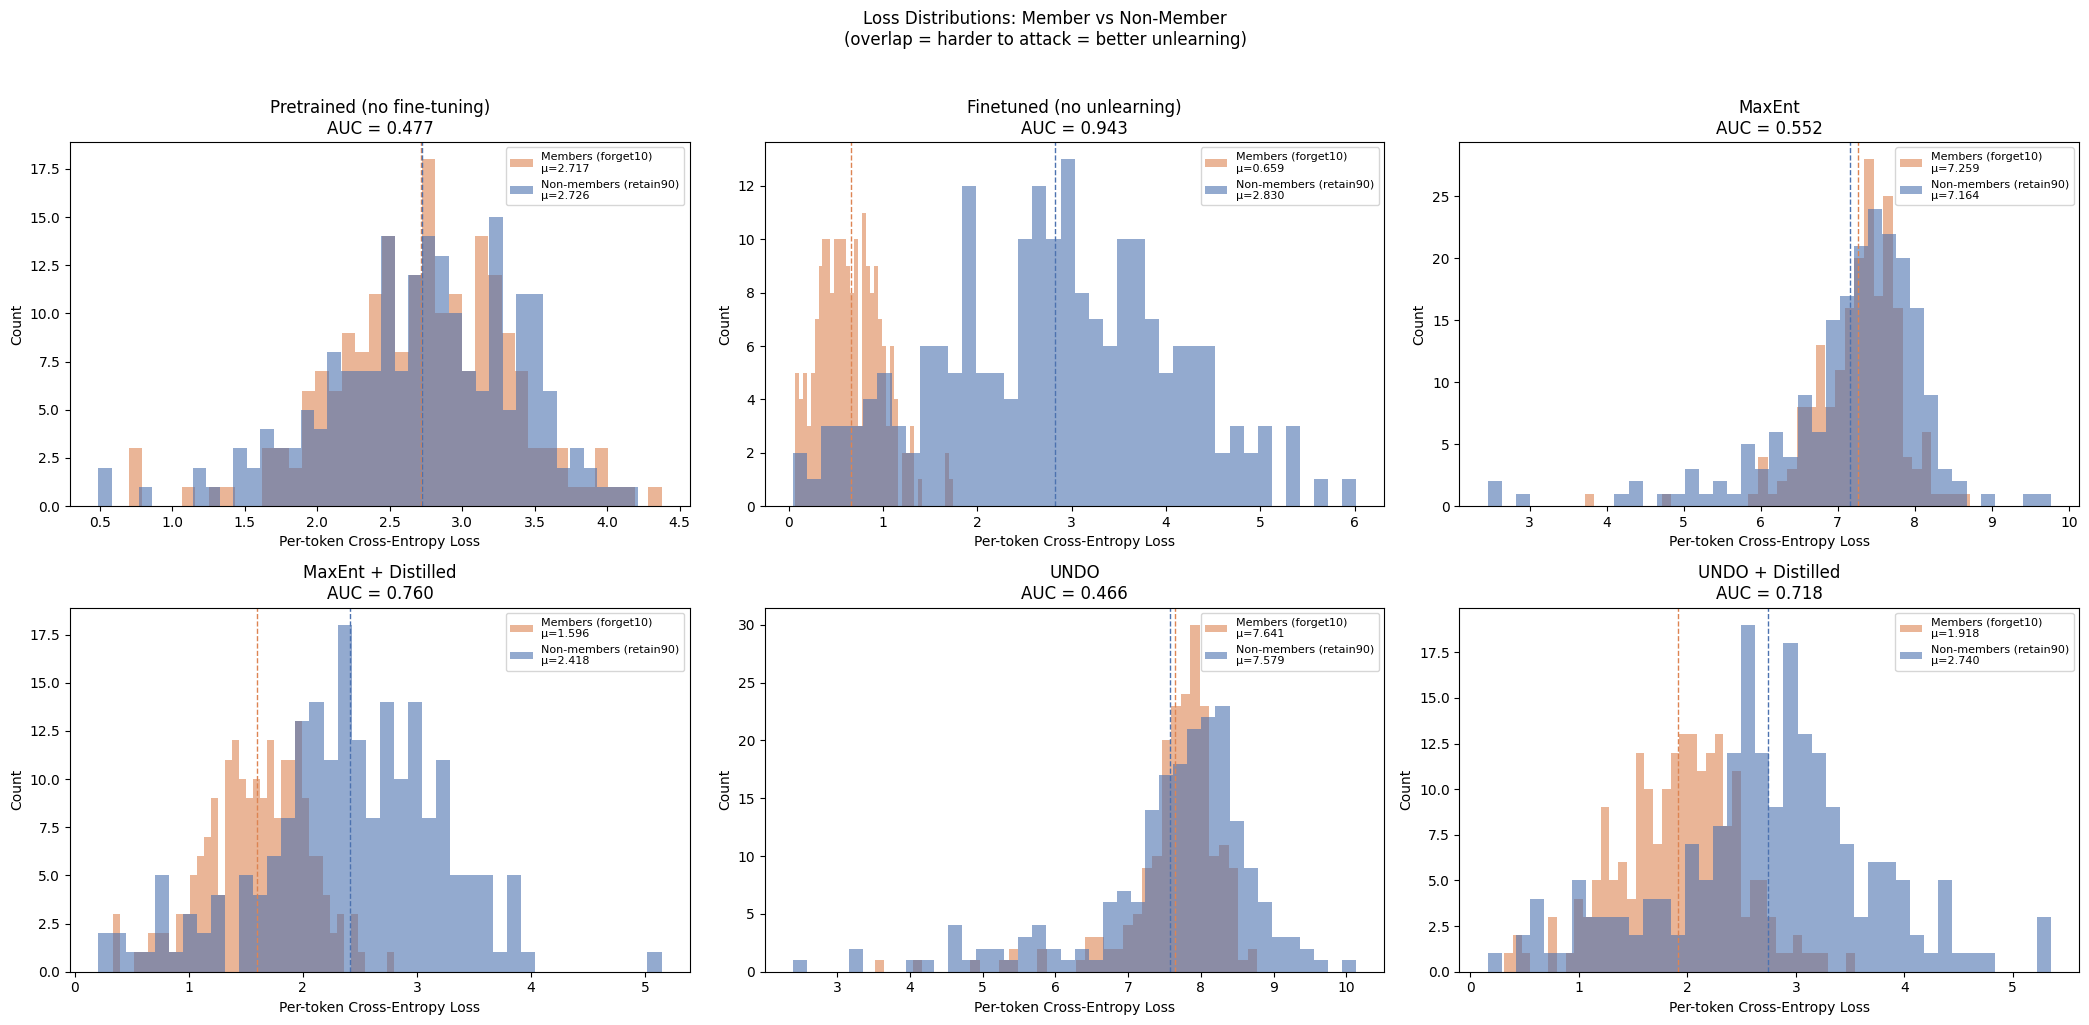

Saved: /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338/notebooks/attacks/results/f3_loss_distributions.png


In [30]:
# Reload losses from results for plotting
n_models = len(MODEL_CONFIGS)
ncols = 3
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
axes = axes.flatten()

for ax, cfg in zip(axes, MODEL_CONFIGS):
    method = cfg["method"]
    row = df[df["Method"] == method]
    if row.empty or pd.isna(row.iloc[0]["AUC"]):
        ax.set_title(f"{method}\n(failed)")
        continue

    try:
        model, tokenizer = load_model(cfg["path"])
        m_losses  = extract_losses(model, tokenizer, member_ds_balanced, "member")
        nm_losses = extract_losses(model, tokenizer, non_member_ds_balanced, "non-member")
        cleanup_model(model)

        auc = row.iloc[0]["AUC"]

        ax.hist(m_losses[np.isfinite(m_losses)],   bins=40, alpha=0.6, color="#DD8452",
                label=f"Members (forget10)\nμ={np.nanmean(m_losses):.3f}")
        ax.hist(nm_losses[np.isfinite(nm_losses)], bins=40, alpha=0.6, color="#4C72B0",
                label=f"Non-members (retain90)\nμ={np.nanmean(nm_losses):.3f}")
        ax.set_title(f"{method}\nAUC = {auc:.3f}")
        ax.set_xlabel("Per-token Cross-Entropy Loss")
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)
        ax.axvline(np.nanmean(m_losses),  color="#DD8452", linestyle="--", linewidth=1)
        ax.axvline(np.nanmean(nm_losses), color="#4C72B0", linestyle="--", linewidth=1)

    except Exception as e:
        ax.set_title(f"{method}\n(plot failed: {e})")

# Hide unused subplots
for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle("Loss Distributions: Member vs Non-Member\n(overlap = harder to attack = better unlearning)", y=1.02)
plt.tight_layout()

out_dir = REPO_DIR / "notebooks/attacks/results"
out_dir.mkdir(parents=True, exist_ok=True)
fig_path = out_dir / "f3_loss_distributions.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


## 9. ROC Curves

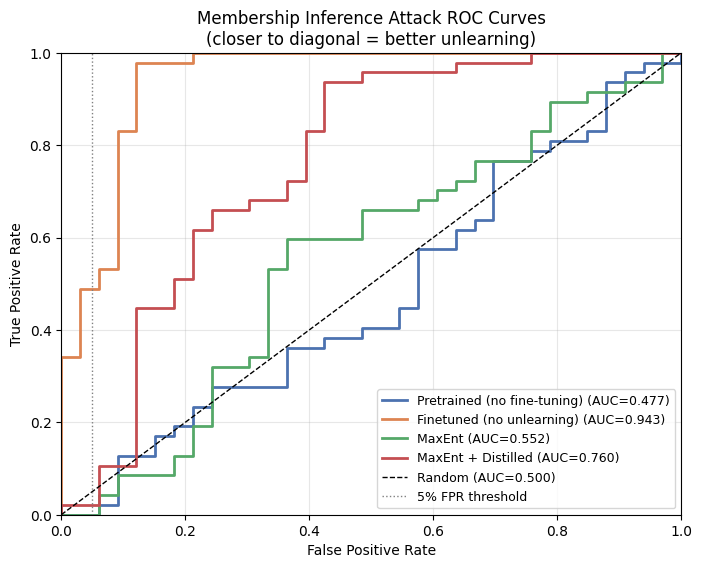

Saved: /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338/notebooks/attacks/results/f3_roc_curves.png


In [31]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for (method, (fpr, tpr)), color in zip(roc_data.items(), colors):
    auc_val = df[df["Method"] == method]["AUC"].iloc[0]
    ax.plot(fpr, tpr, label=f"{method} (AUC={auc_val:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC=0.500)")
ax.axvline(0.05, color="gray", linestyle=":", linewidth=1, label="5% FPR threshold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Membership Inference Attack ROC Curves\n(closer to diagonal = better unlearning)")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(alpha=0.3)

fig_path = out_dir / "f3_roc_curves.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

## 10. Summary Bar Chart

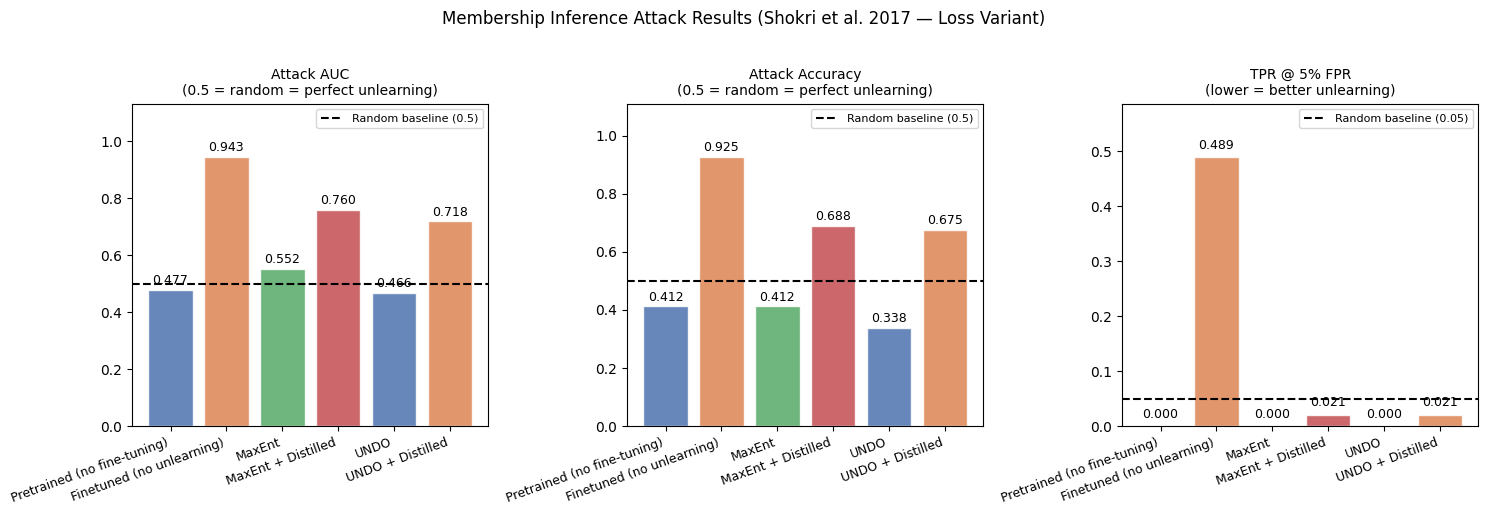

Saved: /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338/notebooks/attacks/results/f3_attack_summary.png


In [32]:
plot_df = df.dropna(subset=["AUC"])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ["AUC", "Accuracy", "TPR @ 5% FPR"]
baselines = [0.5, 0.5, 0.05]
titles = [
    "Attack AUC\n(0.5 = random = perfect unlearning)",
    "Attack Accuracy\n(0.5 = random = perfect unlearning)",
    "TPR @ 5% FPR\n(lower = better unlearning)",
]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for ax, metric, baseline, title in zip(axes, metrics, baselines, titles):
    vals   = plot_df[metric].values
    labels = plot_df["Method"].values
    bars   = ax.bar(range(len(vals)), vals,
                    color=colors[:len(vals)], alpha=0.85, edgecolor="white")
    ax.axhline(baseline, color="black", linestyle="--", linewidth=1.5,
               label=f"Random baseline ({baseline})")
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
    ax.legend(fontsize=8)
    ax.set_ylim(0, max(vals.max() * 1.2, baseline * 1.5))
    for i, v in enumerate(vals):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Membership Inference Attack Results (Shokri et al. 2017 — Loss Variant)", y=1.02)
plt.tight_layout()

fig_path = out_dir / "f3_attack_summary.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

## 11. Save Results

In [33]:
csv_path  = out_dir / "f3_membership_inference_results.csv"
json_path = out_dir / "f3_membership_inference_results.json"

df.to_csv(csv_path, index=False)

with open(json_path, "w") as f:
    json.dump(results, f, indent=2, default=str)

print(f"Saved CSV : {csv_path}")
print(f"Saved JSON: {json_path}")

Saved CSV : /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338/notebooks/attacks/results/f3_membership_inference_results.csv
Saved JSON: /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338/notebooks/attacks/results/f3_membership_inference_results.json


## Notes

### Attack Design

This notebook implements the **loss-threshold** variant of Shokri et al. (2017):

- **Attack signal**: Per-token cross-entropy loss on the target model
- **Attack model**: Logistic regression classifier on the loss value
- **Members**: TOFU `forget10` — records the model was fine-tuned on
- **Non-members**: TOFU `retain90` — records not in the forget set

This is simpler than the full shadow-model attack but is the standard
approach for evaluating LLM unlearning (see TOFU benchmark paper).

### Interpreting AUC

| AUC | Interpretation |
|---|---|
| ~0.50 | Attack at random — unlearning completely removes membership signal |
| 0.55–0.65 | Weak leakage — unlearning mostly effective |
| 0.65–0.75 | Moderate leakage — some membership information remains |
| > 0.75 | Strong leakage — unlearning is incomplete |

### Expected Behaviour

- **MaxEnt** (without distillation) should show near-random AUC on the forget set
  because MaxEnt directly drives the model's loss on forget-set records upward
- **UNDO + Distilled** should also show near-random AUC — distillation repairs
  utility without reintroducing the membership signal
- If distilled models show **lower** AUC than non-distilled, that is evidence that
  distillation makes unlearning *more* robust to membership inference